In [1]:
import astropy.units as u
import FunctionLib as FL
import inspect
from tqdm import tqdm
import astropy
import wave
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import pathlib
import matplotlib as mpl
from matplotlib.colors import LogNorm
from collections import defaultdict
import re
import scipy
import warnings
from astropy.io import fits as asfits

mpl.rcParams['font.family'] = 'serif'


warnings.filterwarnings("ignore")

DJAv4Catalog = FL.Spectrum_Catalog()
DJAv4Catalog.load_from_pkl(os.path.expanduser(
    './DJAV4.2Catalog.pkl'))
print(DJAv4Catalog.sample_num())

DJAv4Catalog.to_dataframe()

3383


,survey_id_subid,prism_filepath,prism_redshift,determined_redshift,grating_filepaths,grating_redshifts,file_count,available_filters,properties,survey_id,grating_within_coverage,sample_flag,reason_for_exclusion,grating_slitloss_correction
0,snh0pe-v4_4446_102,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,0.2259,0.2259,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': nan, 'g235m-f170lp': nan}",3,"{g140m-f100lp, prism-clear, g235m-f170lp}",{'redshift_conflict': False},snh0pe-v4,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,False,[redshift_below_3],{}
1,snh0pe-v4_4446_143,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,1.6318,1.6311,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': 1.6313, 'g235m-f170lp': 1.6309}",3,"{g140m-f100lp, prism-clear, g235m-f170lp}",{'redshift_conflict': False},snh0pe-v4,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,False,[redshift_below_3],{}
2,snh0pe-v4_4446_285,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,0.4446,0.4462,{'g235m-f170lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g235m-f170lp': 0.4462, 'g140m-f100lp': 0.4462}",3,"{g140m-f100lp, prism-clear, g235m-f170lp}",{'redshift_conflict': False},snh0pe-v4,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,False,[redshift_below_3],{}
3,snh0pe-v4_4446_29,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,1.7834,1.77975,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': 1.7799, 'g235m-f170lp': 1.7796}",3,"{g140m-f100lp, prism-clear, g235m-f170lp}",{'redshift_conflict': False},snh0pe-v4,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,False,[redshift_below_3],{}
4,snh0pe-v4_4446_123,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,1.7855,1.7855,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': 1.7855, 'g235m-f170lp': 1.7851}",3,"{g140m-f100lp, prism-clear, g235m-f170lp}",{'redshift_conflict': False},snh0pe-v4,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,False,[redshift_below_3],{}
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43037,glimpse-obs02-v4_9223_9152,None,None,5.5385,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 5.5385},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,{},False,[no_prism_spectrum],{}
43038,glimpse-obs02-v4_9223_98001,None,None,2.6322,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 2.6322},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,{},False,[no_prism_spectrum],{}
43039,glimpse-obs02-v4_9223_47046,None,None,4.3554,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 4.3554},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,{},False,[no_prism_spectrum],{}
43040,glimpse-obs02-v4_9223_45350,None,None,1.3675,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 1.3675},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,{},False,[no_prism_spectrum],{}


In [2]:
DJAv4Catalog.remove_property_field('grating_slitloss_correction')
DJAv4Catalog.add_property_field('grating_slitloss_correction', {})

In [7]:
DJAv4Catalog.remove_property_field('grating_within_coverage')
DJAv4Catalog.add_property_field('grating_within_coverage', {})

In [36]:
DJAv4Catalog.add_property_field('sample_flag', default_value=True)
DJAv4Catalog.add_property_field('reason_for_exclusion', default_value=[])
DJAv4Catalog.add_property_field('grating_within_coverage', default_value={})
DJAv4Catalog.add_property_field('grating_slitloss_correction', default_value={})

In [8]:
for survey_id, catalog in tqdm(DJAv4Catalog.catalog_iterator()):
    prism=catalog['prism_filepath']
    redshift=catalog['determined_redshift']
    if prism is None:
        catalog['sample_flag']=False
        catalog['reason_for_exclusion'].append('no_prism_spectrum')
        DJAv4Catalog.update_catalog_item(survey_id,catalog)
        continue
    if redshift is None:
        catalog['sample_flag']=False
        catalog['reason_for_exclusion'].append('no_redshift')
        DJAv4Catalog.update_catalog_item(survey_id,catalog)
        continue
    if np.isnan(redshift):
        catalog['sample_flag']=False
        catalog['reason_for_exclusion'].append('no_redshift')
        DJAv4Catalog.update_catalog_item(survey_id,catalog)
        continue

    if redshift<3.0:
        catalog['sample_flag']=False
        catalog['reason_for_exclusion'].append('redshift_below_3')
        DJAv4Catalog.update_catalog_item(survey_id,catalog)
        continue

    count=0
    for filter, grating_filepath in catalog['grating_filepaths'].items():
        if grating_filepath is None:
            catalog['sample_flag']=False
            catalog['reason_for_exclusion'].append(f'no_grating_spectrum_{filter}')
            DJAv4Catalog.update_catalog_item(survey_id,catalog)
        grating_redshift=catalog['grating_redshifts'][filter]
        if np.isnan(grating_redshift):
            grating_redshift=redshift
        grating_spectrum = FL.Load_Spectrum_From_Fits(grating_filepath, redshift=grating_redshift)
        inf,sup=grating_spectrum.dual_boundarys()
        if inf<4700*u.AA and sup>6700*u.AA:
            catalog['grating_within_coverage'][filter]=grating_filepath
            count+=1
    if count==0:
        catalog['sample_flag']=False
        catalog['reason_for_exclusion'].append('no_grating_coverage_HaHb')
        DJAv4Catalog.update_catalog_item(survey_id,catalog)
        continue
    else:
        catalog['sample_flag']=True
        DJAv4Catalog.update_catalog_item(survey_id,catalog)

print(DJAv4Catalog.sample_num())
# DJAv4Catalog.save_catalog_to_pkl(pathlib.Path('./DJAV4.2Catalog.pkl').expanduser())

43042it [01:37, 443.46it/s] 

2370


In [2]:
for survey_id, catalog in tqdm(DJAv4Catalog.catalog_iterator()):
    determined_redshift=DJAv4Catalog.determine_redshift(survey_id)
    if determined_redshift is None:
        catalog['sample_flag']=False
        DJAv4Catalog.update_catalog_item(survey_id,catalog)
        continue
    if determined_redshift<3.0:
        catalog['sample_flag']=False
        DJAv4Catalog.update_catalog_item(survey_id,catalog)
        continue
    else:
        DJAv4Catalog.update_catalog_item(survey_id,catalog)
        continue

43042it [00:01, 26734.85it/s]


In [9]:
DJAv4Catalog.to_dataframe()

,survey_id_subid,prism_filepath,prism_redshift,determined_redshift,grating_filepaths,grating_redshifts,file_count,available_filters,properties,survey_id,sample_flag,reason_for_exclusion,grating_slitloss_correction,grating_within_coverage
0,snh0pe-v4_4446_102,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,0.2259,0.2259,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': nan, 'g235m-f170lp': nan}",3,"{g140m-f100lp, prism-clear, g235m-f170lp}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3, redshift_...",{},{}
1,snh0pe-v4_4446_143,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,1.6318,1.6311,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': 1.6313, 'g235m-f170lp': 1.6309}",3,"{g140m-f100lp, prism-clear, g235m-f170lp}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3, redshift_...",{},{}
2,snh0pe-v4_4446_285,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,0.4446,0.4462,{'g235m-f170lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g235m-f170lp': 0.4462, 'g140m-f100lp': 0.4462}",3,"{g140m-f100lp, prism-clear, g235m-f170lp}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3, redshift_...",{},{}
3,snh0pe-v4_4446_29,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,1.7834,1.77975,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': 1.7799, 'g235m-f170lp': 1.7796}",3,"{g140m-f100lp, prism-clear, g235m-f170lp}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3, redshift_...",{},{}
4,snh0pe-v4_4446_123,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,1.7855,1.7855,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': 1.7855, 'g235m-f170lp': 1.7851}",3,"{g140m-f100lp, prism-clear, g235m-f170lp}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3, redshift_...",{},{}
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43037,glimpse-obs02-v4_9223_9152,None,None,5.5385,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 5.5385},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,"[no_prism_spectrum, no_prism_spectrum, no_pris...",{},{}
43038,glimpse-obs02-v4_9223_98001,None,None,2.6322,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 2.6322},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,"[no_prism_spectrum, no_prism_spectrum, no_pris...",{},{}
43039,glimpse-obs02-v4_9223_47046,None,None,4.3554,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 4.3554},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,"[no_prism_spectrum, no_prism_spectrum, no_pris...",{},{}
43040,glimpse-obs02-v4_9223_45350,None,None,1.3675,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 1.3675},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,"[no_prism_spectrum, no_prism_spectrum, no_pris...",{},{}


In [10]:
DJAv4Catalog.save_catalog_to_pkl(pathlib.Path('./DJAV4.2Catalog.pkl').expanduser())

0it [00:00, ?it/s]

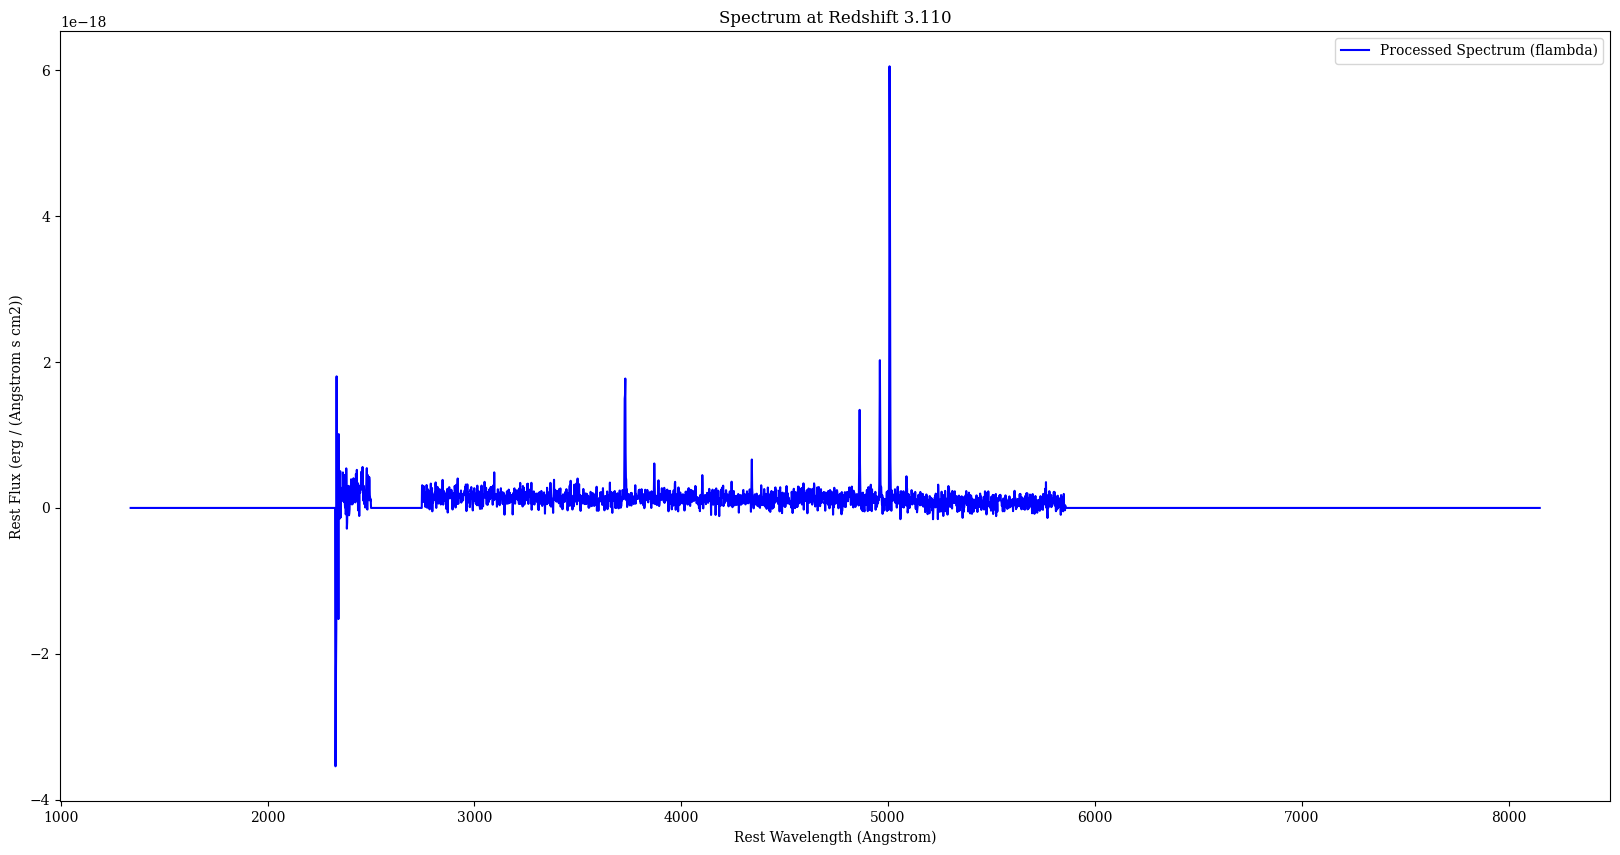

15it [00:00, 92.45it/s]

(<Quantity 0.23282071 micron>, <Quantity 0.58570177 micron>)


In [ ]:
for id, catalog in tqdm(DJAv4Catalog.catalog_iterator(100)):
    if catalog['sample_flag']!=True:
        continue

    redshift=catalog['determined_redshift']

    for disperser_filter, grating_filename in catalog.get('grating_within_coverage', {}).items():

        grating_spec=FL.Load_Spectrum_From_Fits(grating_filename, redshift=redshift)
        grating_spec.show()
        print(grating_spec.dual_boundarys())


    break